## Smart Grid Forecaster — Data Cleaning & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df_raw = pd.read_csv("PowerLoad_Dataset.csv")
print(f"Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Shape: (10000, 10)


,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
0,2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,1,0,508.96,519.14
1,2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,1,0,522.95,533.41
2,2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,1,0,527.55,538.10
3,2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,1,0,506.71,516.85
4,2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,2,0,481.05,498.31


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Timestamp                      10000 non-null  str    
 1   Power_Load_kW                  10000 non-null  float64
 2   Temperature_C                  10000 non-null  float64
 3   Humidity_%                     10000 non-null  float64
 4   WindSpeed_mps                  10000 non-null  float64
 5   Precipitation_mm               10000 non-null  float64
 6   DayOfWeek                      10000 non-null  int64  
 7   HolidayFlag                    10000 non-null  int64  
 8   Daily_PostDispatch_Load        10000 non-null  float64
 9   Weekly_PreDispatch_Projection  10000 non-null  float64
dtypes: float64(7), int64(2), str(1)
memory usage: 781.4 KB


In [4]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Power_Load_kW,10000.0,499.397814,49.880756,308.17,465.4675,499.985,532.90,680.57
Temperature_C,10000.0,25.022674,7.026358,-5.00,20.2000,25.050,29.69,45.00
Humidity_%,10000.0,60.126286,17.334169,30.00,45.0775,60.230,74.96,89.99
WindSpeed_mps,10000.0,7.516845,4.346676,0.00,3.7575,7.560,11.27,15.00
Precipitation_mm,10000.0,0.202565,0.204053,0.00,0.0600,0.140,0.28,2.16
DayOfWeek,10000.0,3.982500,2.010771,1.00,2.0000,4.000,6.00,7.00
HolidayFlag,10000.0,0.285400,0.451627,0.00,0.0000,0.000,1.00,1.00
Daily_PostDispatch_Load,10000.0,500.112020,10.137719,463.76,493.3300,500.110,506.77,539.85
Weekly_PreDispatch_Projection,10000.0,509.946114,3.916816,493.59,507.3700,510.030,512.57,538.10


### Data Quality Assessment

In [5]:
missing = df_raw.isnull().sum()

missing[missing>0]

Series([], dtype: int64)

In [6]:
print(
    "Duplicate rows:",
    df_raw.duplicated().sum()
)

Duplicate rows: 0


In [7]:
timestamp_check = pd.to_datetime(df_raw['Timestamp'])

print(
    "Duplicate timestamps:",
    timestamp_check.duplicated().sum()
)

Duplicate timestamps: 0


### Time Stamp Processing

In [8]:
df = df_raw.copy()

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df = df.sort_values(
    'Timestamp'
).reset_index(drop=True)


df.head()

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
0,2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,1,0,508.96,519.14
1,2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,1,0,522.95,533.41
2,2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,1,0,527.55,538.10
3,2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,1,0,506.71,516.85
4,2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,2,0,481.05,498.31


In [9]:
##Missing Hour Analysis

start = df['Timestamp'].min()
end = df['Timestamp'].max()


full_range = pd.date_range(
    start=start,
    end=end,
    freq="h"
)


print("Start:",start)
print("End:",end)

print(
    "Expected hourly records:",
    len(full_range)
)

print(
    "Actual records:",
    len(df)
)

Start: 2018-01-01 01:00:00
End: 2023-06-30 16:00:00
Expected hourly records: 48160
Actual records: 10000


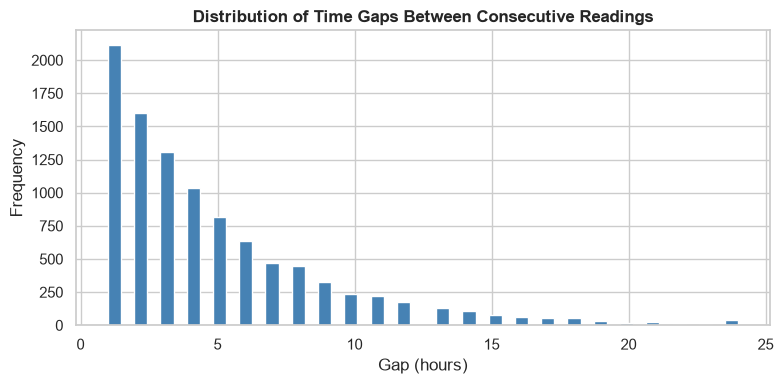

count    9999.000000
mean        4.816382
std         4.265176
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        47.000000
Name: Timestamp, dtype: float64


In [10]:
gap_hours = df['Timestamp'].diff().dropna().dt.total_seconds() / 3600

plt.figure(figsize=(8, 4))
gap_hours.clip(upper=24).plot(kind='hist', bins=48, color='steelblue')

plt.title("Distribution of Time Gaps Between Consecutive Readings")
plt.xlabel("Gap (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(gap_hours.describe())

### Missing Timestamp Handling

Interpolation Strategy: 
Only gaps <= 6 hours are interpolated.
Long gaps are removed because they would create artificial data.

In [11]:
MAX_GAP_HOURS = 6


df_indexed = df.set_index(
    'Timestamp'
)


columns_to_interpolate = [
    'Power_Load_kW',
    'Temperature_C',
    'Humidity_%',
    'WindSpeed_mps',
    'Precipitation_mm',
    'Daily_PostDispatch_Load',
    'Weekly_PreDispatch_Projection'
]


df_full = (
    df_indexed[columns_to_interpolate + ['HolidayFlag']]
    .reindex(full_range)
)


df_full.index.name="Timestamp"

In [12]:
original_missing = (df_full['Power_Load_kW'].isna())


df_clean = (
    df_full[columns_to_interpolate]
    .interpolate(
        method='time',
        limit=MAX_GAP_HOURS,
        limit_direction='both'
    )
)

# HolidayFlag is categorical (0/1), so time-interpolation doesn't make sense
# for it. Short gaps are filled by carrying the flag from the nearest known
# hour instead, using the same max-gap rule as everything else.
df_clean['HolidayFlag'] = (
    df_full['HolidayFlag']
    .ffill(limit=MAX_GAP_HOURS)
    .bfill(limit=MAX_GAP_HOURS)
)

df_clean['Is_Interpolated'] = (
    original_missing &
    df_clean['Power_Load_kW'].notna()
)

print(f"Original observations : {(~df_clean['Is_Interpolated']).sum():,}")
print(f"Interpolated (short gap): {df_clean['Is_Interpolated'].sum():,}")

Original observations : 12,223
Interpolated (short gap): 35,937


In [13]:
df_clean = (
    df_clean
    .dropna(
        subset=['Power_Load_kW']
    )
    .reset_index()
)

df_clean['HolidayFlag'] = df_clean['HolidayFlag'].astype(int)

df_clean.shape

(45937, 10)

### Feature Engineering

In [14]:
df_clean['Hour'] = ( df_clean['Timestamp'].dt.hour)
df_clean['DayOfWeek'] = (df_clean['Timestamp'].dt.dayofweek + 1)
df_clean['IsWeekend'] = (df_clean['DayOfWeek'].isin([6,7]).astype(int))
df_clean['Month'] = (df_clean['Timestamp'].dt.month)
df_clean['Year'] = (df_clean['Timestamp'].dt.year)

# Lag features, computed against a continuous hourly grid so "previous hour"
# and "previous day" always mean exactly that. df_clean itself has rows
# missing wherever a gap was too long to interpolate, so shifting directly
# on df_clean would silently pull values from several hours/days earlier
# whenever a row follows a dropped gap. Reindexing to a full hourly grid
# first means a lag value comes back as NaN instead when it isn't truly
# available, rather than a wrong-but-plausible number.
_hourly_series = (
    df_clean
    .set_index('Timestamp')['Power_Load_kW']
    .reindex(pd.date_range(df_clean['Timestamp'].min(), df_clean['Timestamp'].max(), freq='h'))
)

df_clean['Load_previous_hour'] = (
    _hourly_series.shift(1).reindex(df_clean['Timestamp']).values
)

df_clean['Load_previous_day'] = (
    _hourly_series.shift(24).reindex(df_clean['Timestamp']).values
)

### Outlier Detection

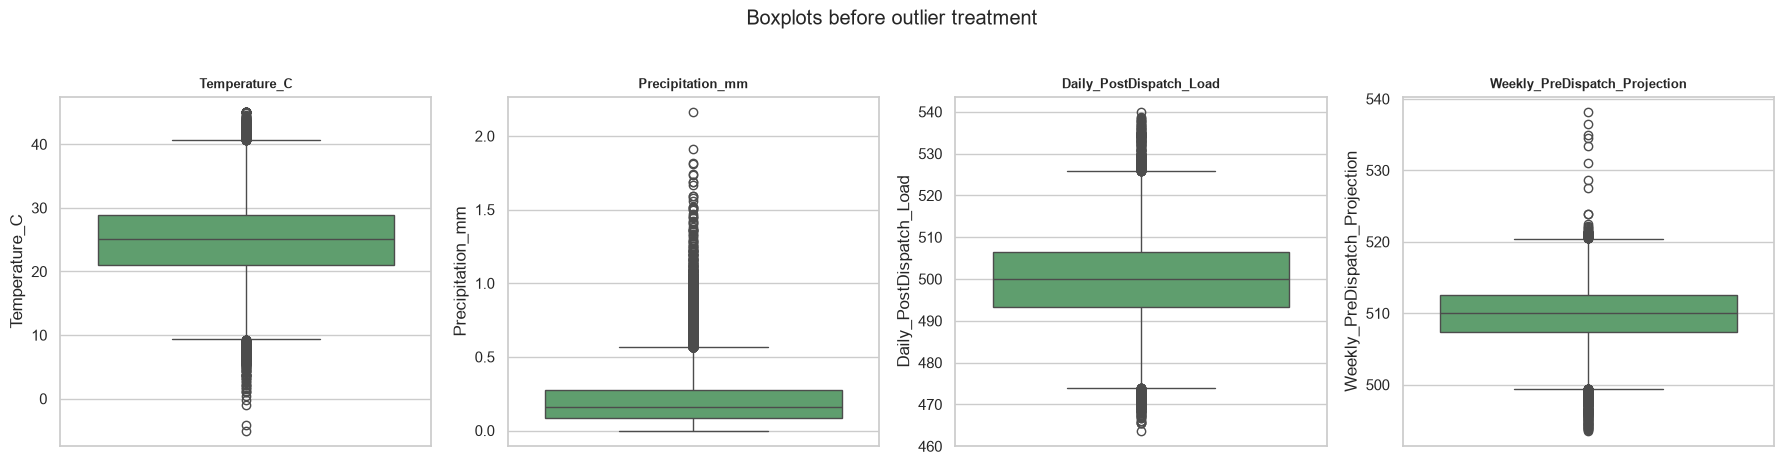

In [15]:
outlier_cols = ['Temperature_C', 'Precipitation_mm',
                 'Daily_PostDispatch_Load', 'Weekly_PreDispatch_Projection']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4.5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='#55A868')
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots before outlier treatment', y=1.03)
plt.tight_layout()
plt.show()


In [16]:
outlier_summary = {}

for col in outlier_cols:
    Q1 = df_clean[col].quantile(.25)
    Q3 = df_clean[col].quantile(.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary[col] = n_outliers

    # Cap (winsorize) rather than drop outlier rows outright, so the hourly
    # time series stays continuous and lag features keep working correctly.
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

pd.Series(outlier_summary, name='outliers_capped')

Temperature_C                     426
Precipitation_mm                 2007
Daily_PostDispatch_Load           355
Weekly_PreDispatch_Projection     425
Name: outliers_capped, dtype: int64

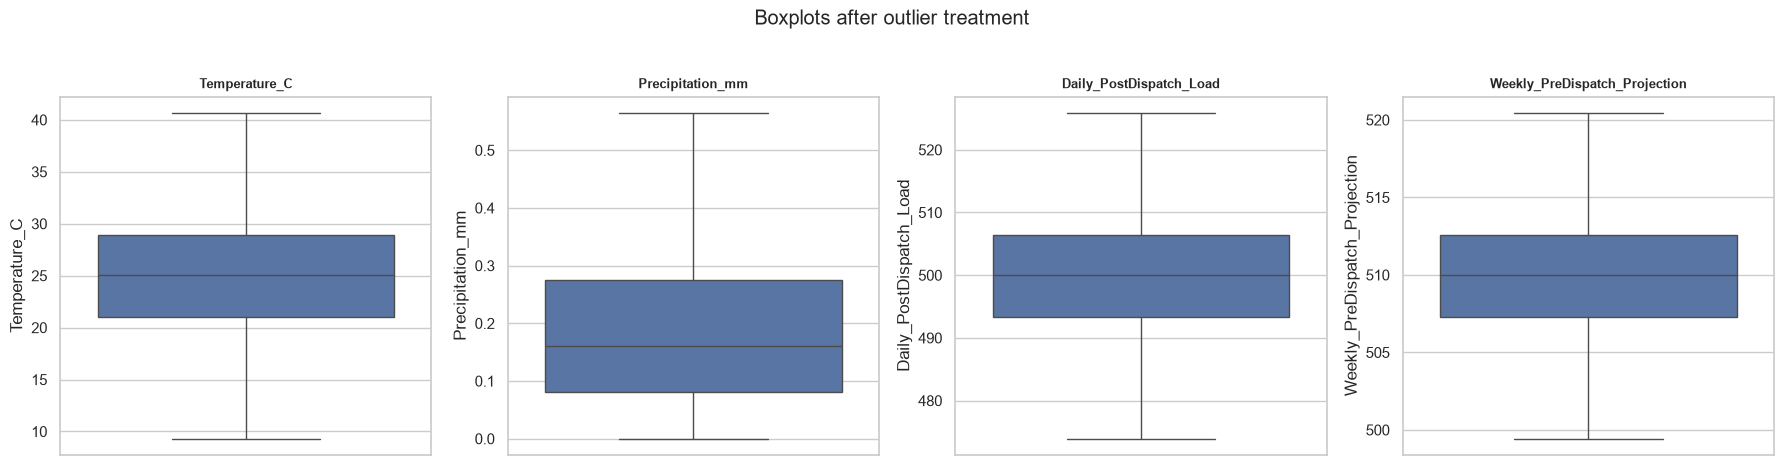

In [17]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4.5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots after outlier treatment', y=1.03)
plt.tight_layout()
plt.show()

In [18]:
# Reduces skewness caused by extreme rainfall values.
df_clean['Precipitation_mm_log'] = np.log1p(df_clean['Precipitation_mm'])

### Final Dataset Export

In [19]:
# Final sorting

final_order = [
    'Timestamp',
    'Year',
    'Month',
    'DayOfWeek',
    'IsWeekend',
    'Hour',
    'HolidayFlag',
    'Is_Interpolated',
    'Power_Load_kW',
    'Temperature_C',
    'Humidity_%',
    'WindSpeed_mps',
    'Precipitation_mm',
    'Precipitation_mm_log',
    'Daily_PostDispatch_Load',
    'Weekly_PreDispatch_Projection',
    'Load_previous_hour',
    'Load_previous_day'
]

df_clean = df_clean[final_order]
df_clean = df_clean.round(2)

# Export cleaned dataset
df_clean.to_csv("cleaned_load_data.csv", index=False)

print("Final cleaned dataset saved to",  "cleaned_load_data.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_1812\3362685420.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_clean = df_clean.round(2)


Final cleaned dataset saved to cleaned_load_data.csv


### EDA

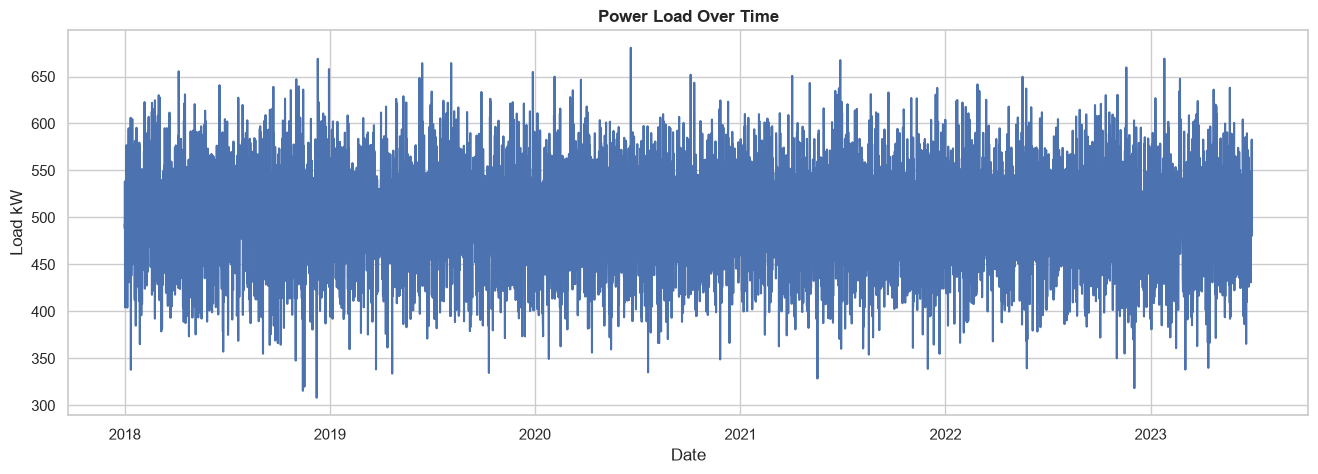

In [20]:
plt.figure(figsize=(16,5))

plt.plot(df_clean['Timestamp'],df_clean['Power_Load_kW'])
plt.title("Power Load Over Time")
plt.xlabel("Date")
plt.ylabel("Load kW")

plt.show()

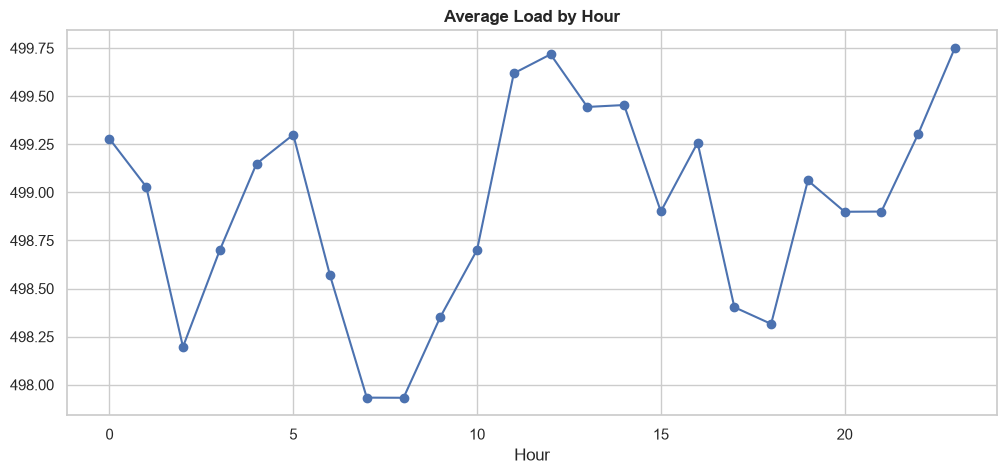

In [21]:
hourly_avg = (df_clean.groupby('Hour')['Power_Load_kW'].mean())
hourly_avg.plot(marker='o')
plt.title("Average Load by Hour")

plt.show()

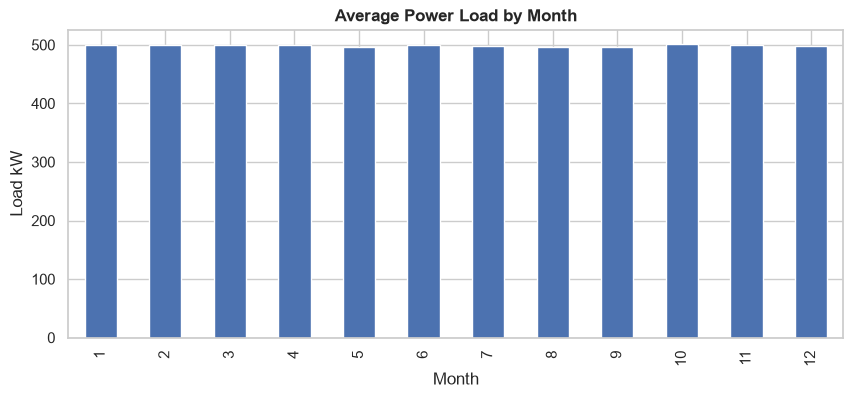

In [22]:
monthly_load = (
    df_clean
    .groupby('Month')['Power_Load_kW']
    .mean()
)


monthly_load.plot(
    kind='bar',
    figsize=(10,4)
)

plt.title("Average Power Load by Month")
plt.xlabel("Month")
plt.ylabel("Load kW")

plt.show()

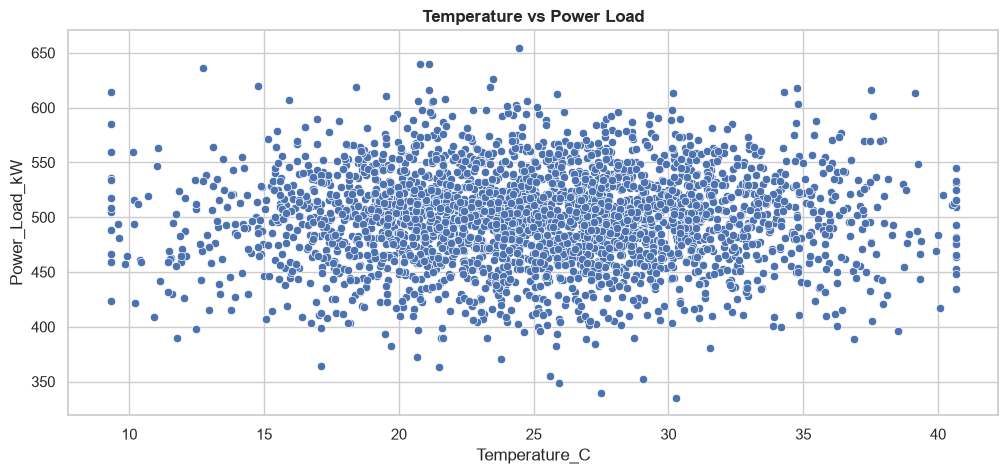

In [23]:
sns.scatterplot(
    data=df_clean.sample(3000),
    x='Temperature_C',
    y='Power_Load_kW'
)

plt.title(
    "Temperature vs Power Load"
)

plt.show()

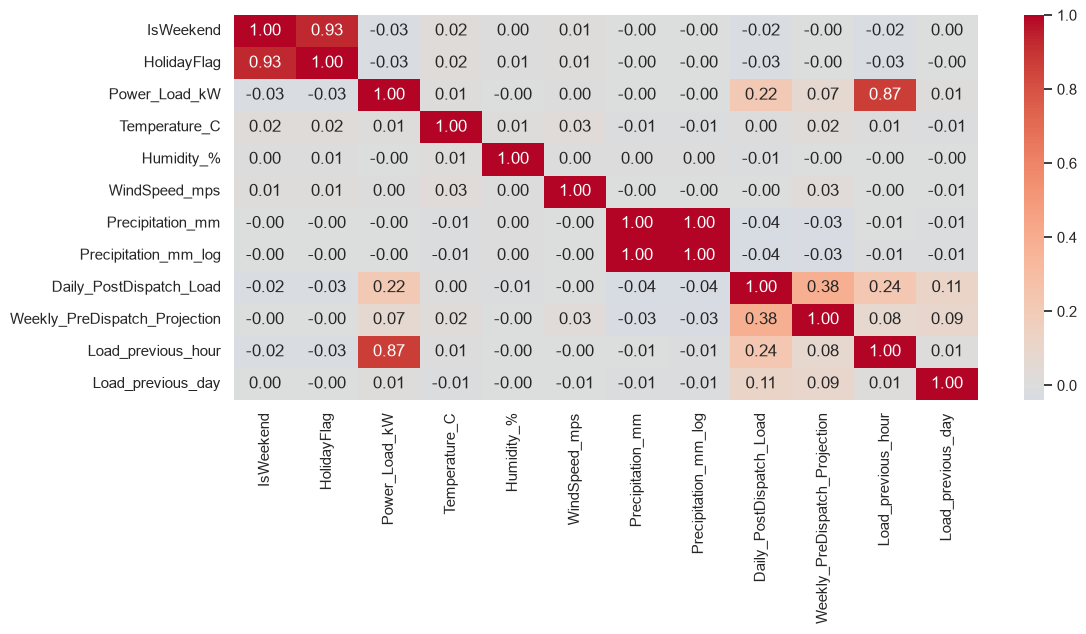

In [24]:
corr_cols = df_clean.select_dtypes(
    include=['int64', 'float64']
).columns

sns.heatmap(
    df_clean[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.show()